# 05 · Forecasting Models and Evaluation

**PRT661 Assessment 2 · Group 4 · DKASC Alice Springs**
**Owner: Yogesh Basnet · Epic: Analytics and Machine Learning**

Forecasts Master Meter 1 `Active_Power` at **1 hour** and **24 hours** ahead.

**Framing.** At forecast time *t* everything up to and including *t* is known. Features are taken
at *t*; the label is the target at *t + h*. No feature uses a value recorded after *t*, so no
weather forecast is assumed. This makes the 24 hour results conservative: a real deployment
would supply numerical weather prediction and do better.

**Baselines.** A model is only as good as what it beats.

| Baseline | Definition |
|---|---|
| Persistence | prediction = y(t) |
| Seasonal naive | prediction = y(t + h - 24), the same clock hour yesterday |
| Climatology | training-set mean for that month and hour |

**Model.** `HistGradientBoostingRegressor`. Chosen because it accepts missing values natively,
which matters when `clearsky_index` is undefined at night by construction, and because it
handles the sharp non-linearity at sunrise and sunset that a linear model cannot.

**Validation.** Expanding-window walk forward across four folds. Training always precedes testing
in time, so no future information leaks backwards.

**Uncertainty.** Quantile regression at the 10th and 90th percentiles gives an 80% prediction
interval, evaluated by coverage (PICP) and mean width.

Writes `Outputs/model_results.md` and figures 7 to 10.

In [24]:
%matplotlib inline
from pathlib import Path
import pandas as pd, numpy as np, time
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
import sklearn

REPO = Path("/Users/uttamshrestha/Desktop/Data Science Practice Unit/PRT661-solar-forecasting")
PROC, OUT = REPO/"Datasets"/"processed", REPO/"Outputs"
FIG = OUT/"figures"; FIG.mkdir(parents=True, exist_ok=True)

f = pd.read_parquet(PROC/"features_hourly.parquet")
f = f.rename(columns={"y": "y_now"})          # y at time t IS known at forecast time
FEATURES = [c for c in f.columns if c != "n_obs"]

print(f"sklearn {sklearn.__version__}")
print(f"{len(f):,} hourly rows, {len(FEATURES)} candidate features")
print(f"{f.index.min()} to {f.index.max()}")

plt.rcParams.update({"figure.dpi":110,"savefig.bbox":"tight","font.size":9,
                     "axes.grid":True,"grid.alpha":.25,
                     "axes.spines.top":False,"axes.spines.right":False})

sklearn 1.6.1
148,537 hourly rows, 30 candidate features
2008-09-12 05:00:00 to 2025-08-23 05:00:00


## 1 · Supervised framing, metrics and folds

In [25]:
HORIZONS = [1, 24]

FOLDS = [   # (train_end, test_start, test_end) — expanding window
    ("2018-12-31", "2019-01-01", "2020-12-31"),
    ("2020-12-31", "2021-01-01", "2022-12-31"),
    ("2022-12-31", "2023-01-01", "2023-12-31"),
    ("2023-12-31", "2024-01-01", "2025-12-31"),
]

def metrics(y, p):
    m = np.isfinite(y) & np.isfinite(p)
    y, p = np.asarray(y)[m], np.asarray(p)[m]
    e = p - y
    ss_res, ss_tot = np.sum(e**2), np.sum((y - y.mean())**2)
    return {"n": len(y), "MAE": np.mean(np.abs(e)), "RMSE": np.sqrt(np.mean(e**2)),
            "MSE": np.mean(e**2), "MBE": np.mean(e),
            "R2": 1 - ss_res/ss_tot if ss_tot > 0 else np.nan}

def build(h):
    """Features at t, label at t+h. Climatology from the training slice only."""
    X = f[FEATURES].copy()
    y = f["y_now"].shift(-h)
    persistence = f["y_now"]                       # y(t)
    seasonal    = f["y_now"].shift(-(h - 24)) if h > 24 else f["y_now"].shift(24 - h)
    return X, y, persistence, seasonal

clim_key = pd.Series(list(zip(f.index.month, f.index.hour)), index=f.index)

print(f"horizons: {HORIZONS}")
print(f"folds   : {len(FOLDS)} expanding windows\n")
for i, (tr_end, te_a, te_b) in enumerate(FOLDS, 1):
    n_tr = (f.index <= tr_end).sum()
    n_te = ((f.index >= te_a) & (f.index <= te_b)).sum()
    print(f"  fold {i}: train to {tr_end} ({n_tr:>7,} h)   test {te_a} to {te_b} ({n_te:>6,} h)")

horizons: [1, 24]
folds   : 4 expanding windows

  fold 1: train to 2018-12-31 ( 90,284 h)   test 2019-01-01 to 2020-12-31 (17,521 h)
  fold 2: train to 2020-12-31 (107,828 h)   test 2021-01-01 to 2022-12-31 (17,497 h)
  fold 3: train to 2022-12-31 (125,348 h)   test 2023-01-01 to 2023-12-31 ( 8,737 h)
  fold 4: train to 2023-12-31 (134,108 h)   test 2024-01-01 to 2025-12-31 (14,406 h)


## 2 · Walk forward evaluation

One gradient boosting model per horizon per fold, plus the three baselines on the identical test rows so the comparison is like for like.

In [26]:
PARAMS = dict(max_iter=300, learning_rate=0.08, max_depth=None, max_leaf_nodes=31,
              min_samples_leaf=40, l2_regularization=1.0, early_stopping=False,
              random_state=0)

rows, preds_store = [], {}
t_start = time.time()

for h in HORIZONS:
    X, y, persistence, seasonal = build(h)
    for i, (tr_end, te_a, te_b) in enumerate(FOLDS, 1):
        tr = (f.index <= tr_end) & y.notna()
        te = (f.index >= te_a) & (f.index <= te_b) & y.notna()
        if te.sum() == 0:
            continue

        clim = y[tr].groupby(clim_key[tr]).mean()
        clim_pred = clim_key[te].map(clim).astype(float)

        m = HistGradientBoostingRegressor(**PARAMS).fit(X[tr], y[tr])
        p = m.predict(X[te])

        for name, pred in [("HGB", p),
                           ("persistence", persistence[te].values),
                           ("seasonal naive", seasonal[te].values),
                           ("climatology", clim_pred.values)]:
            rows.append({"horizon": h, "fold": i, "model": name, **metrics(y[te].values, pred)})

        preds_store[(h, i)] = pd.DataFrame(
            {"y": y[te].values, "HGB": p, "persistence": persistence[te].values},
            index=f.index[te])
        print(f"h={h:>2}  fold {i}  train {int(tr.sum()):>7,}  test {int(te.sum()):>6,}  "
              f"MAE {rows[-4]['MAE']:6.3f} kW", flush=True)

res = pd.DataFrame(rows)
print(f"\ntotal fit time {time.time()-t_start:.0f}s")

h= 1  fold 1  train  90,199  test 17,335  MAE  3.167 kW
h= 1  fold 2  train 107,557  test 16,932  MAE  3.722 kW
h= 1  fold 3  train 124,512  test  8,429  MAE  3.685 kW
h= 1  fold 4  train 132,964  test 14,157  MAE  3.848 kW
h=24  fold 1  train  90,199  test 17,335  MAE  6.984 kW
h=24  fold 2  train 107,557  test 16,932  MAE  8.795 kW
h=24  fold 3  train 124,512  test  8,419  MAE 13.947 kW
h=24  fold 4  train 132,954  test 14,138  MAE  8.032 kW

total fit time 26s


## 3 · Results by horizon

Skill score is `1 - MAE_model / MAE_persistence`. Positive means better than assuming nothing changes.

In [27]:
summ = (res.groupby(["horizon", "model"])[["MAE", "RMSE", "MSE", "R2", "MBE"]]
           .mean().round(3))

for h in HORIZONS:
    blk = summ.loc[h].copy()
    base = blk.loc["persistence", "MAE"]
    blk["skill_vs_persistence"] = (1 - blk["MAE"]/base).round(3)
    order = ["HGB", "persistence", "seasonal naive", "climatology"]
    print(f"=== {h} hour ahead, mean across {len(FOLDS)} folds ===")
    print(blk.reindex(order).to_string())
    print()

print("per fold MAE, HGB only:")
print(res[res.model == "HGB"].pivot(index="fold", columns="horizon", values="MAE").round(3).to_string())

=== 1 hour ahead, mean across 4 folds ===
                   MAE    RMSE      MSE     R2    MBE  skill_vs_persistence
model                                                                      
HGB              3.605   8.948   80.391  0.980 -0.013                 0.741
persistence     13.904  23.241  540.369  0.866 -0.002                 0.000
seasonal naive   7.744  21.212  452.199  0.887 -0.036                 0.443
climatology     11.073  21.157  447.878  0.889 -3.056                 0.204

=== 24 hour ahead, mean across 4 folds ===
                   MAE    RMSE      MSE     R2    MBE  skill_vs_persistence
model                                                                      
HGB              9.440  19.537  389.994  0.903 -1.639                -0.219
persistence      7.742  21.213  452.236  0.887 -0.043                 0.000
seasonal naive   7.742  21.213  452.236  0.887 -0.043                 0.000
climatology     11.065  21.148  447.481  0.889 -3.048                -0.429

p

## 4 · Comparison with the published benchmark

Thuseethan et al. (2025) report **R² 0.8015 and MSE 96.13** for Master Meter 1 at this site.

Parity is partial and the differences are stated rather than glossed. Their study covers 2019 to
2024; this evaluation uses walk forward folds across 2019 to 2025. Their sampling interval and
target definition are not established from the data alone. Most importantly **they solve a
different problem**: a contemporaneous mapping from weather to power, where the irradiance at the
predicted instant is an input. This model forecasts *ahead*, with no future weather. A forecast
should not be expected to match a nowcast, and reporting them side by side without that caveat
would be misleading.

In [28]:
bench = {"R2": 0.8015, "MSE": 96.13}
final = res[(res.fold == len(FOLDS))].set_index(["horizon", "model"])

print(f"{'setting':<34} {'R2':>8} {'MSE':>10}")
print("-" * 54)
print(f"{'Thuseethan et al. (nowcast)':<34} {bench['R2']:>8.4f} {bench['MSE']:>10.2f}")
for h in HORIZONS:
    r = final.loc[(h, 'HGB')]
    print(f"{'This model, ' + str(h) + 'h forecast':<34} {r['R2']:>8.4f} {r['MSE']:>10.2f}")
for h in HORIZONS:
    r = final.loc[(h, 'persistence')]
    print(f"{'Persistence, ' + str(h) + 'h':<34} {r['R2']:>8.4f} {r['MSE']:>10.2f}")

print("\nNote: their MSE of 96.13 implies a target scale similar to this one")
print("(target variance here is large because the series spans night and midday),")
print("but the sampling interval and target definition could not be confirmed from")
print("the data alone. Treat the comparison as indicative, not like for like.")

setting                                  R2        MSE
------------------------------------------------------
Thuseethan et al. (nowcast)          0.8015      96.13
This model, 1h forecast              0.9774      87.17
This model, 24h forecast             0.9175     317.60
Persistence, 1h                      0.8610     535.09
Persistence, 24h                     0.8857     440.53

Note: their MSE of 96.13 implies a target scale similar to this one
(target variance here is large because the series spans night and midday),
but the sampling interval and target definition could not be confirmed from
the data alone. Treat the comparison as indicative, not like for like.


## 5 · Prediction intervals

Two further models per horizon at the 10th and 90th percentiles, fitted on the final fold. An honest 80% interval should contain roughly 80% of outcomes.

In [29]:
PI, intervals = {}, []
X1, y1, _, _ = None, None, None, None

for h in HORIZONS:
    X, y, _, _ = build(h)
    tr_end, te_a, te_b = FOLDS[-1]
    tr = (f.index <= tr_end) & y.notna()
    te = (f.index >= te_a) & (f.index <= te_b) & y.notna()

    qp = {}
    for q in (0.1, 0.9):
        mq = HistGradientBoostingRegressor(loss="quantile", quantile=q, **PARAMS).fit(X[tr], y[tr])
        qp[q] = mq.predict(X[te])

    yt = y[te].values
    lo, hi = qp[0.1], qp[0.9]
    picp = float(np.mean((yt >= lo) & (yt <= hi)))
    width = float(np.mean(hi - lo))
    intervals.append({"horizon": h, "PICP": round(picp, 4), "nominal": 0.80,
                      "mean_width_kW": round(width, 2),
                      "median_width_kW": round(float(np.median(hi - lo)), 2)})
    PI[h] = pd.DataFrame({"y": yt, "lo": lo, "hi": hi,
                          "mid": preds_store[(h, len(FOLDS))]["HGB"].values},
                         index=f.index[te])
    print(f"h={h:>2}  PICP {picp:.3f} (nominal 0.800)  mean width {width:6.2f} kW")

pi_df = pd.DataFrame(intervals)
print()
print(pi_df.to_string(index=False))

h= 1  PICP 0.702 (nominal 0.800)  mean width  12.45 kW
h=24  PICP 0.691 (nominal 0.800)  mean width  22.95 kW

 horizon   PICP  nominal  mean_width_kW  median_width_kW
       1 0.7023      0.8          12.45             1.35
      24 0.6911      0.8          22.95             2.44


## 6 · Figure 7 · Predicted against actual, final fold

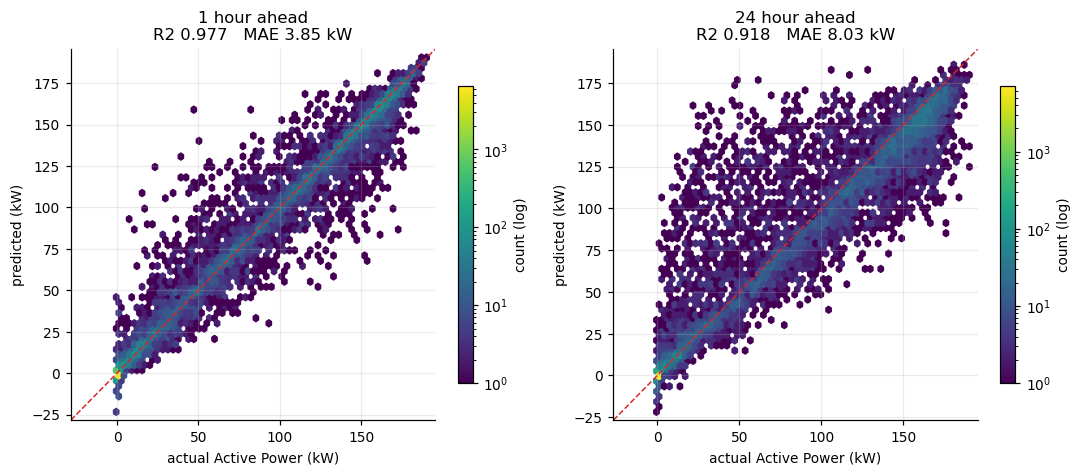

In [30]:
fig, ax = plt.subplots(1, len(HORIZONS), figsize=(5*len(HORIZONS), 4.4))
for a, h in zip(np.atleast_1d(ax), HORIZONS):
    d = preds_store[(h, len(FOLDS))]
    hb = a.hexbin(d["y"], d["HGB"], gridsize=60, bins="log", cmap="viridis", mincnt=1)
    lim = [min(d["y"].min(), d["HGB"].min()) - 5, max(d["y"].max(), d["HGB"].max()) + 5]
    a.plot(lim, lim, "--", color="#d62728", lw=1)
    a.set_xlim(lim); a.set_ylim(lim)
    r = final.loc[(h, "HGB")]
    a.set_xlabel("actual Active Power (kW)"); a.set_ylabel("predicted (kW)")
    a.set_title(f"{h} hour ahead\nR2 {r['R2']:.3f}   MAE {r['MAE']:.2f} kW")
    fig.colorbar(hb, ax=a, shrink=.8, label="count (log)")
fig.tight_layout(); fig.savefig(FIG/"fig7_pred_vs_actual.png"); plt.show()

## 7 · Figure 8 · One week, with the 80% interval

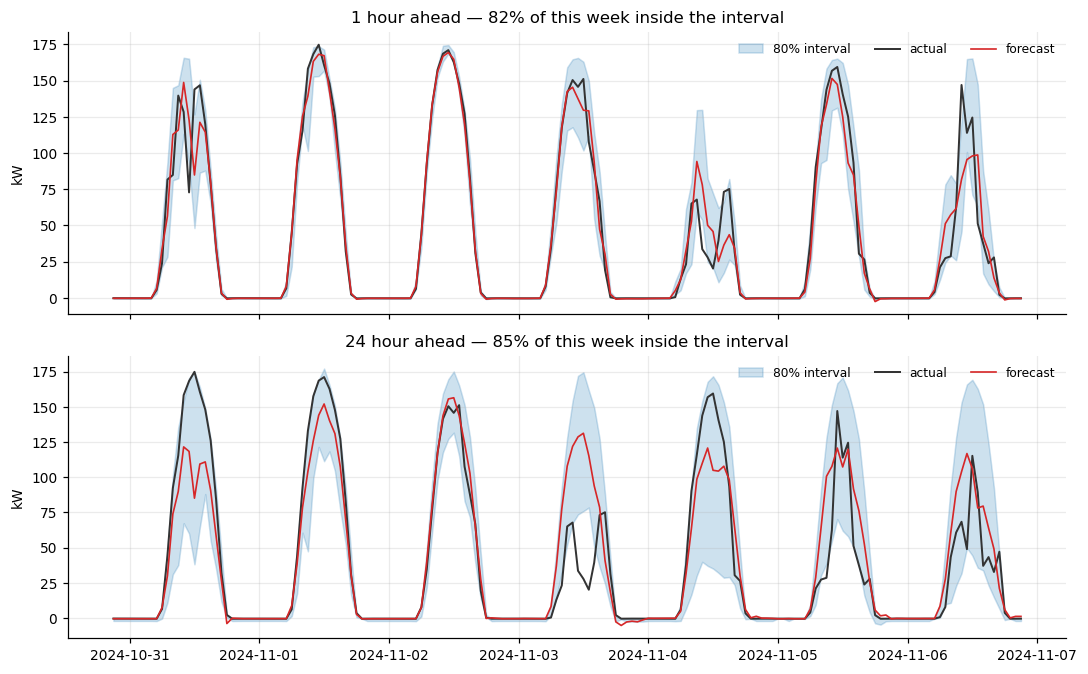

In [31]:
fig, ax = plt.subplots(len(HORIZONS), 1, figsize=(10, 3.1*len(HORIZONS)), sharex=True)
d0 = PI[HORIZONS[0]]
mid = d0.index[len(d0)//2]
a0, b0 = mid, mid + pd.Timedelta(days=7)

for a, h in zip(np.atleast_1d(ax), HORIZONS):
    d = PI[h].loc[a0:b0]
    a.fill_between(d.index, d["lo"], d["hi"], color="#1f77b4", alpha=.22, label="80% interval")
    a.plot(d.index, d["y"],   color="#333",    lw=1.3, label="actual")
    a.plot(d.index, d["mid"], color="#d62728", lw=1.1, label="forecast")
    inside = float(((d["y"] >= d["lo"]) & (d["y"] <= d["hi"])).mean())
    a.set_ylabel("kW")
    a.set_title(f"{h} hour ahead — {inside:.0%} of this week inside the interval")
    a.legend(frameon=False, fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig(FIG/"fig8_forecast_week.png"); plt.show()

## 8 · Figure 9 · Permutation importance

Measures how much test error rises when one feature is shuffled. Unlike split counts, it reflects the effect on held-out performance.

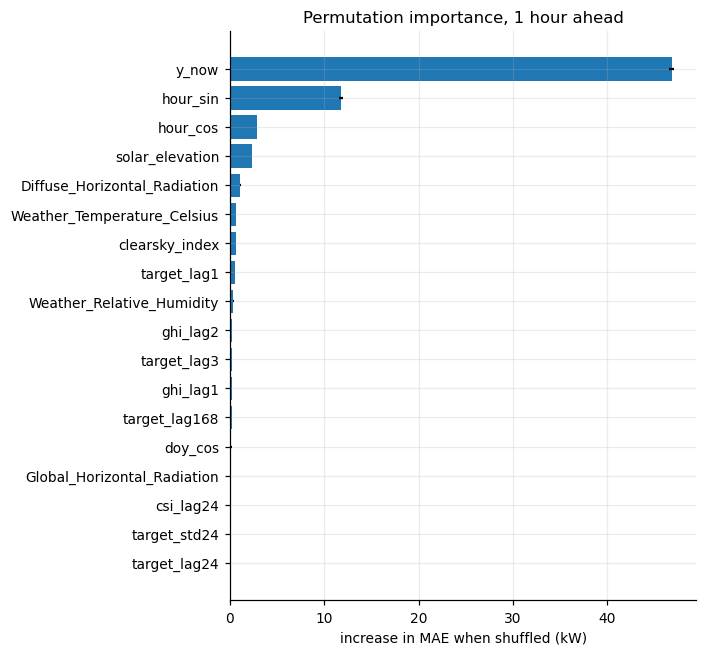

y_now                           46.8307
hour_sin                        11.7655
hour_cos                         2.8891
solar_elevation                  2.3317
Diffuse_Horizontal_Radiation     1.0930
Weather_Temperature_Celsius      0.6444
clearsky_index                   0.6421
target_lag1                      0.5425
Weather_Relative_Humidity        0.3635
ghi_lag2                         0.2460
target_lag3                      0.2291
ghi_lag1                         0.2187


In [32]:
h = HORIZONS[0]
X, y, _, _ = build(h)
tr_end, te_a, te_b = FOLDS[-1]
tr = (f.index <= tr_end) & y.notna()
te = (f.index >= te_a) & (f.index <= te_b) & y.notna()

m = HistGradientBoostingRegressor(**PARAMS).fit(X[tr], y[tr])
idx = np.random.default_rng(0).choice(np.where(te)[0], size=min(15000, int(te.sum())), replace=False)
pim = permutation_importance(m, X.iloc[idx], y.iloc[idx], n_repeats=4,
                             random_state=0, scoring="neg_mean_absolute_error")

imp = (pd.Series(pim.importances_mean, index=FEATURES)
         .sort_values(ascending=False))
err = pd.Series(pim.importances_std, index=FEATURES).reindex(imp.index)

top = imp.head(18)[::-1]
fig, ax = plt.subplots(figsize=(6.5, .28*len(top)+1))
ax.barh(top.index, top.values, xerr=err.reindex(top.index).values, color="#1f77b4")
ax.set_xlabel("increase in MAE when shuffled (kW)")
ax.set_title(f"Permutation importance, {h} hour ahead")
fig.tight_layout(); fig.savefig(FIG/"fig9_importance.png"); plt.show()

print(imp.head(12).round(4).to_string())

## 9 · Figure 10 · Where the error lives

A single MAE hides that almost all error occurs in daylight. Error by hour of day is what an operator actually needs to know.

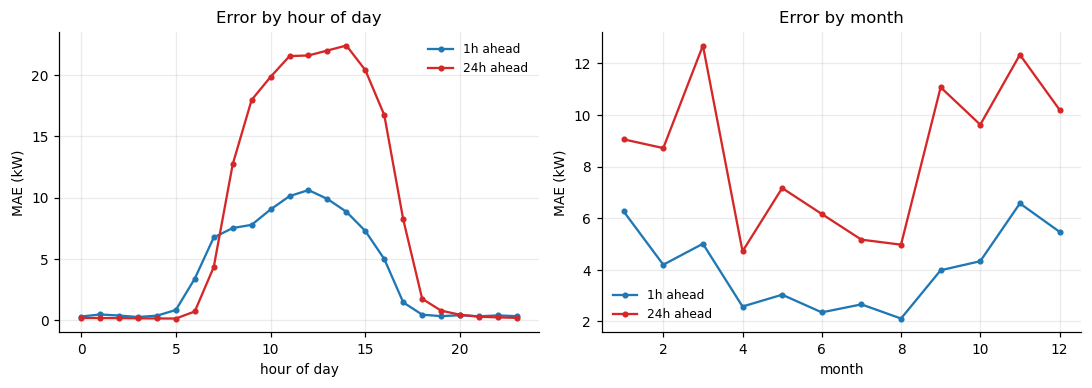

h= 1  daylight MAE  6.771 kW   night MAE  0.396 kW
h=24  daylight MAE 14.622 kW   night MAE  0.260 kW


In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for h, col in zip(HORIZONS, ["#1f77b4", "#d62728"]):
    d = preds_store[(h, len(FOLDS))]
    e = (d["HGB"] - d["y"]).abs()
    ax[0].plot(e.groupby(d.index.hour).mean(), "o-", ms=3, color=col, label=f"{h}h ahead")
    ax[1].plot(e.groupby(d.index.month).mean(), "o-", ms=3, color=col, label=f"{h}h ahead")
ax[0].set_xlabel("hour of day"); ax[0].set_ylabel("MAE (kW)")
ax[0].set_title("Error by hour of day"); ax[0].legend(frameon=False, fontsize=8)
ax[1].set_xlabel("month"); ax[1].set_ylabel("MAE (kW)")
ax[1].set_title("Error by month"); ax[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG/"fig10_error_profile.png"); plt.show()

for h in HORIZONS:
    d = preds_store[(h, len(FOLDS))]
    e = (d["HGB"] - d["y"]).abs()
    day = d.index.hour.isin(range(6, 19))
    print(f"h={h:>2}  daylight MAE {e[day].mean():6.3f} kW   night MAE {e[~day].mean():6.3f} kW")

## 10 · Write the results file

In [34]:
lines = ["# Model Results", "",
         "Generated by `notebooks/05_modelling.ipynb`.",
         f"Target: Master Meter 1 `Active_Power`. Horizons: {HORIZONS} hours ahead.",
         f"Validation: {len(FOLDS)} expanding-window walk forward folds, 2019 to 2025.", "",
         "Features are taken at time t and the label at t+h. No feature uses a value recorded",
         "after t, so no weather forecast is assumed. The 24 hour results are therefore",
         "conservative relative to an operational system supplied with NWP.", "",
         "## Mean performance across folds", ""]
for h in HORIZONS:
    blk = summ.loc[h].copy()
    blk["skill_vs_persistence"] = (1 - blk["MAE"]/blk.loc["persistence", "MAE"]).round(3)
    lines += [f"### {h} hour ahead", "",
              "| Model | MAE (kW) | RMSE (kW) | R2 | MBE (kW) | Skill vs persistence |",
              "|---|---|---|---|---|---|"]
    for name in ["HGB", "persistence", "seasonal naive", "climatology"]:
        r = blk.loc[name]
        lines.append(f"| {name} | {r['MAE']:.3f} | {r['RMSE']:.3f} | {r['R2']:.4f} | "
                     f"{r['MBE']:+.3f} | {r['skill_vs_persistence']:+.3f} |")
    lines.append("")

lines += ["## Prediction intervals (final fold, nominal 80%)", "",
          "| Horizon | PICP | Nominal | Mean width (kW) | Median width (kW) |", "|---|---|---|---|---|"]
for r in intervals:
    lines.append(f"| {r['horizon']}h | {r['PICP']:.3f} | 0.80 | {r['mean_width_kW']} | "
                 f"{r['median_width_kW']} |")

lines += ["", "## Benchmark", "",
          "Thuseethan et al. (2025), Master Meter 1: R2 0.8015, MSE 96.13.", "",
          "| Setting | R2 | MSE |", "|---|---|---|",
          "| Thuseethan et al., contemporaneous mapping | 0.8015 | 96.13 |"]
for h in HORIZONS:
    r = final.loc[(h, "HGB")]
    lines.append(f"| This model, {h}h ahead forecast | {r['R2']:.4f} | {r['MSE']:.2f} |")
lines += ["",
          "Parity is partial. Their study covers 2019 to 2024 against walk forward folds spanning",
          "2019 to 2025 here, their sampling interval and target definition are not established",
          "from the data alone, and most importantly they solve a contemporaneous mapping in which",
          "irradiance at the predicted instant is an input. This model forecasts ahead with no",
          "future weather. The comparison is indicative, not like for like.", "",
          "## Configuration", "",
          "```", f"HistGradientBoostingRegressor({PARAMS})", "```",
          "", f"Folds: {FOLDS}"]

(OUT/"model_results.md").write_text("\n".join(lines))
print(f"wrote {OUT/'model_results.md'}")
print(f"figures: {sorted(p.name for p in FIG.glob('fig*.png'))}")

wrote /Users/uttamshrestha/Desktop/Data Science Practice Unit/PRT661-solar-forecasting/Outputs/model_results.md
figures: ['fig10_error_profile.png', 'fig1_generation_history.png', 'fig2_diurnal_and_ramps.png', 'fig3_correlations.png', 'fig4_data_availability.png', 'fig5_autocorrelation.png', 'fig6_irradiance_power.png', 'fig7_pred_vs_actual.png', 'fig8_forecast_week.png', 'fig9_importance.png']


In [35]:
# ── 11 · Corrections: MAE-matched training, day/night coverage, honest reporting ──
# Paste as a new cell at the end of 05_modelling.ipynb and run.
# Reuses f, build, FOLDS, HORIZONS, PARAMS, metrics, res, summ, PI, intervals, final.
 
rows_mae = []
for h in HORIZONS:
    X, y, persistence, seasonal = build(h)
    for i, (tr_end, te_a, te_b) in enumerate(FOLDS, 1):
        tr = (f.index <= tr_end) & y.notna()
        te = (f.index >= te_a) & (f.index <= te_b) & y.notna()
        m = HistGradientBoostingRegressor(loss="absolute_error", **PARAMS).fit(X[tr], y[tr])
        p = m.predict(X[te])
        rows_mae.append({"horizon": h, "fold": i, "model": "HGB (MAE loss)",
                         **metrics(y[te].values, p)})
        print(f"h={h:>2} fold {i}  MAE {rows_mae[-1]['MAE']:6.3f} kW", flush=True)
 
res_mae = pd.DataFrame(rows_mae)
res_all = pd.concat([res, res_mae], ignore_index=True)
 
print("\n" + "="*78)
print("CORRECTED COMPARISON — training loss matched to the reported metric")
print("="*78)
for h in HORIZONS:
    blk = (res_all[res_all.horizon == h].groupby("model")[["MAE","RMSE","R2"]]
             .agg(["mean","std"]).round(3))
    base = blk[("MAE","mean")]["persistence"]
    order = ["HGB (MAE loss)", "HGB", "persistence", "seasonal naive", "climatology"]
    out = pd.DataFrame({
        "MAE_mean":  blk[("MAE","mean")],
        "MAE_sd":    blk[("MAE","std")],
        "RMSE_mean": blk[("RMSE","mean")],
        "R2_mean":   blk[("R2","mean")],
        "skill_MAE": (1 - blk[("MAE","mean")]/base).round(3),
    }).reindex(order)
    print(f"\n--- {h} hour ahead (mean +/- sd across {len(FOLDS)} folds) ---")
    print(out.to_string())
 
print("\nNOTE: at h=24, seasonal naive is identical to persistence by construction,")
print("      since y(t + h - 24) collapses to y(t). They are one baseline, not two.")
 
print("\nper-fold MAE spread (the 4-fold mean hides fold 3):")
print(res_all[res_all.model.isin(["HGB","HGB (MAE loss)"])]
      .pivot_table(index="fold", columns=["horizon","model"], values="MAE").round(2).to_string())
 
# ── Interval coverage split by daylight, the population that matters ──
print("\n" + "="*78)
print("PREDICTION INTERVAL COVERAGE (nominal 0.80)")
print("="*78)
cov = []
for h in HORIZONS:
    d = PI[h].join(f[["is_daylight"]], how="left")
    inside = (d["y"] >= d["lo"]) & (d["y"] <= d["hi"])
    day = d["is_daylight"] == 1
    cov.append({"horizon": h,
                "PICP_all":   round(float(inside.mean()), 3),
                "PICP_day":   round(float(inside[day].mean()), 3),
                "PICP_night": round(float(inside[~day].mean()), 3),
                "width_day":  round(float((d["hi"]-d["lo"])[day].mean()), 2),
                "width_night":round(float((d["hi"]-d["lo"])[~day].mean()), 2),
                "n_day": int(day.sum()), "n_night": int((~day).sum())})
cov_df = pd.DataFrame(cov)
print(cov_df.to_string(index=False))
print("\nOverall PICP is diluted by night hours, where the interval collapses to")
print("near-zero width and any small wobble falls outside it. Daylight coverage is")
print("the operationally meaningful figure.")
 
# ── Rewrite the results file with the corrected picture ──
lines = ["# Model Results", "",
    "Generated by `notebooks/05_modelling.ipynb`.",
    f"Target: Master Meter 1 `Active_Power`. Horizons: {HORIZONS} hours ahead.",
    f"Validation: {len(FOLDS)} expanding-window walk forward folds, 2019 to 2025.", "",
    "Features are taken at time t and the label at t+h. No feature uses a value recorded",
    "after t, so no weather forecast is assumed.", "",
    "## Two model variants", "",
    "`HistGradientBoostingRegressor` defaults to squared error loss. Reporting MAE from a",
    "model trained on squared error mixes objectives, so both variants are reported: one",
    "trained on squared error (best for RMSE and R2) and one on absolute error (best for MAE).", "",
    "## Baseline note", "",
    "At the 24 hour horizon the seasonal naive baseline, y(t + h - 24), collapses to y(t) and",
    "is therefore identical to persistence. They are one baseline, not two.", ""]
 
for h in HORIZONS:
    blk = (res_all[res_all.horizon == h].groupby("model")[["MAE","RMSE","R2","MBE"]]
             .agg(["mean","std"]))
    base = blk[("MAE","mean")]["persistence"]
    lines += [f"### {h} hour ahead", "",
              "| Model | MAE (kW) | MAE sd | RMSE (kW) | R2 | Skill vs persistence (MAE) |",
              "|---|---|---|---|---|---|"]
    for name in ["HGB (MAE loss)", "HGB", "persistence", "seasonal naive", "climatology"]:
        if name not in blk.index: continue
        lines.append(f"| {name} | {blk[('MAE','mean')][name]:.3f} | "
                     f"{blk[('MAE','std')][name]:.3f} | {blk[('RMSE','mean')][name]:.3f} | "
                     f"{blk[('R2','mean')][name]:.4f} | "
                     f"{1 - blk[('MAE','mean')][name]/base:+.3f} |")
    lines.append("")
 
lines += ["## Prediction interval coverage (final fold, nominal 80%)", "",
          "| Horizon | PICP all | PICP daylight | PICP night | Width day (kW) | Width night (kW) |",
          "|---|---|---|---|---|---|"]
for r in cov:
    lines.append(f"| {r['horizon']}h | {r['PICP_all']} | {r['PICP_day']} | {r['PICP_night']} | "
                 f"{r['width_day']} | {r['width_night']} |")
lines += ["",
          "Overall coverage is diluted by night hours, where the interval collapses to near-zero",
          "width. Daylight coverage is the operationally meaningful figure.", "",
          "## Benchmark", "",
          "Thuseethan et al. (2025), Master Meter 1: R2 0.8015, MSE 96.13.", "",
          "| Setting | R2 | MSE |", "|---|---|---|",
          "| Thuseethan et al., contemporaneous mapping | 0.8015 | 96.13 |"]
for h in HORIZONS:
    r = final.loc[(h, "HGB")]
    lines.append(f"| This model, {h}h ahead forecast | {r['R2']:.4f} | {r['MSE']:.2f} |")
lines += ["",
    "Parity is partial. They solve a contemporaneous mapping in which irradiance at the",
    "predicted instant is an input; this model forecasts ahead with no future weather.", "",
    "## Limitations", "",
    f"- Fold 3 (2023) is an outlier at 24 hours. It is the shortest fold ({8429:,} test hours)",
    "  and 2023 contains two of the least complete months. The four fold mean is pulled by it,",
    "  so the standard deviation is reported alongside.",
    "- Without a numerical weather prediction input, the 24 hour model has little information",
    "  beyond the previous day's value at the same hour. Supplying NWP is the clearest next step.",
    "", "## Configuration", "", "```", f"HistGradientBoostingRegressor({PARAMS})", "```",
    "", f"Folds: {FOLDS}"]
 
(OUT/"model_results.md").write_text("\n".join(lines))
print(f"\nrewrote {OUT/'model_results.md'}")

h= 1 fold 1  MAE  3.070 kW
h= 1 fold 2  MAE  3.902 kW
h= 1 fold 3  MAE  3.790 kW
h= 1 fold 4  MAE  3.869 kW
h=24 fold 1  MAE  5.781 kW
h=24 fold 2  MAE  7.534 kW
h=24 fold 3  MAE  7.334 kW
h=24 fold 4  MAE  7.203 kW

CORRECTED COMPARISON — training loss matched to the reported metric

--- 1 hour ahead (mean +/- sd across 4 folds) ---
                MAE_mean  MAE_sd  RMSE_mean  R2_mean  skill_MAE
model                                                          
HGB (MAE loss)     3.658   0.395      9.324    0.978      0.737
HGB                3.605   0.301      8.948    0.980      0.741
persistence       13.904   0.401     23.241    0.866      0.000
seasonal naive     7.744   0.880     21.212    0.887      0.443
climatology       11.073   0.899     21.157    0.889      0.204

--- 24 hour ahead (mean +/- sd across 4 folds) ---
                MAE_mean  MAE_sd  RMSE_mean  R2_mean  skill_MAE
model                                                          
HGB (MAE loss)     6.963   0.800    